Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [2]:
INTERGENIC_TES_DISTANCES = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\TE_Intergenic_With_Distances.bed"
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_KO\\Expression_TE_DESeq_KO.csv"
THRESHOLD_DISTANCE = 4000
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\SraRunTable_Liu24.csv"

Histogram

     0      1      2               3     4  5    6     7     8      9      10  \
0  chr1  40307  40626     TE_L2a_dup3   747  +   L2  LINE  chr1  29553  31109   
1  chr1  48416  49518  TE_L1PA14_dup1  5956  +   L1  LINE  chr1  52472  53312   
2  chr1  51584  51880  TE_AluYj4_dup1  2373  +  Alu  SINE  chr1  52472  53312   
3  chr1  54464  54703      TE_L2_dup1   529  +   L2  LINE  chr1  52472  53312   
4  chr1  54818  54938  TE_FLAM_A_dup1   680  -  Alu  SINE  chr1  34553  36081   

            11 12 13     14  
0  MIR1302-2HG  .  +   9199  
1       OR4G4P  .  +   2955  
2       OR4G4P  .  +    593  
3       OR4G4P  .  +   1153  
4      FAM138A  .  -  18738  
     Start     End  Count
0      1.0   500.9   7276
1    500.9  1000.8   6794
2   1000.8  1500.7   6775
3   1500.7  2000.6   6573
4   2000.6  2500.5   6227
5   2500.5  3000.4   6050
6   3000.4  3500.3   5925
7   3500.3  4000.2   5687
8   4000.2  4500.1   5421
9   4500.1  5000.0   5216
10  5000.0  5499.9   5038
11  5499.9  5999.8   

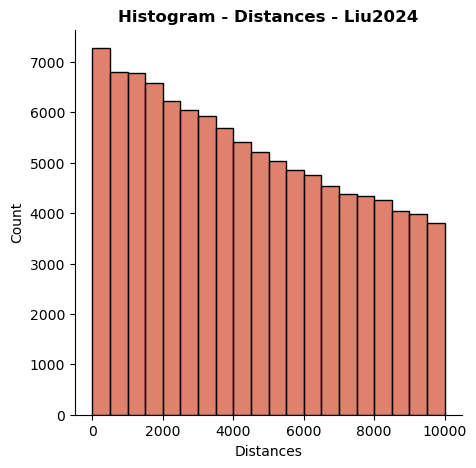

In [3]:
TEs_df = pd.read_csv(INTERGENIC_TES_DISTANCES, sep = '\t', header = None)
print(TEs_df.head())

TEs_df.columns = ['TE_Chr', 'TE_Start', 'TE_End', 'TE_Name', 'TE_Score', 'TE_Strand', 'TE_Class-id', 'TE_Family_id',
                 'Gene_Chr', 'Gene_Start', 'Gene_End', 'Gene_Name', 'Gene_Score', 'Gene_Strand', 'Distances']

def plot_histogram(df):
    fig, ax = plt.subplots(figsize = (5,5))

    final_df = df[df['Distances'] < 10000]

    sns.histplot(data = final_df, x = 'Distances', bins = 20, color = '#D5573B')

    ax.set_title('Histogram - Distances - Liu2024', fontweight = 'bold', fontsize = 12)
    sns.despine()
    plt.plot()
    get_count(ax)

def get_count(ax): # Alternativamente podia utilizar o numpy.histogram
    patches = ax.patches # Uma patch é um objeto gráfico 2D que representa uma forma geométrica (ou seja é tipo os pontos e as barras)
    bin_count = []
    bin_edges = []

    for patch in patches: # Só há 20 barras, há uma que não vai ficar nas edges
        bin_count.append(patch.get_height()) # Também podia ter feito bin_count = [patch for patch in patches], mas assim é mais eficiente
        bin_edges.append(patch.get_x())

    bin_width = patch.get_width()
    bin_edges.append(patches[-1].get_x() + bin_width) # Para conseguir a última edge

    hist_df = pd.DataFrame( {
                'Start' : bin_edges[:-1],
                'End' : bin_edges[1:],
                'Count' : bin_count
    }
    )
    print(hist_df)

plot_histogram(TEs_df)


PCA Intergenics - Data

In [4]:
# Read files
expr_df = pd.read_csv(EXPRESSION_FILE)
clinical_df = pd.read_csv(CLINICAL_DATA)

# Merge to get intergenic
expr_df = expr_df.rename(columns = {'Unnamed: 0' : 'TE_Name'})
TEs_df = TEs_df[['TE_Name']]
expr_df = expr_df.merge(TEs_df, on = 'TE_Name', how = 'inner')

# Organize and extract expression file
TEs_names = expr_df['TE_Name']
counts = expr_df.iloc[:, 1:]

# Organize clinical data
clinical_df = clinical_df[['Sample Name', 'Run', 'genotype']]
print(clinical_df)

# Make log2cpm
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)


# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

# PCA
pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# Merge it all
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)]) # Os nomes das amostras ficam como index e as colunas são as componentes principais
pca_df.reset_index(names = 'Sample Name', inplace = True)
pca_df = pca_df.merge(clinical_df, on = 'Sample Name', how = 'left')
pca_df.head()


   Sample Name          Run     genotype
0   GSM7232994  SRR24321482     MECP2.WT
1   GSM7232993  SRR24321483     MECP2.WT
2   GSM7232992  SRR24321484     MECP2.WT
3   GSM7232991  SRR24321485  MECP2.R168X
4   GSM7232990  SRR24321486  MECP2.R168X
5   GSM7232989  SRR24321487  MECP2.R168X
6   GSM7232988  SRR24321488  MECP2.R133C
7   GSM7232987  SRR24321489  MECP2.R133C
8   GSM7232986  SRR24321490  MECP2.R133C
9   GSM7232985  SRR24321491     MECP2.KO
10  GSM7232984  SRR24321492     MECP2.KO
11  GSM7232983  SRR24321493     MECP2.KO


,Sample Name,PC1,PC2,Run,genotype
0,GSM7232994,-433.153865,-149.133401,SRR24321482,MECP2.WT
1,GSM7232993,-249.486024,-154.589163,SRR24321483,MECP2.WT
2,GSM7232992,-481.427267,-139.697169,SRR24321484,MECP2.WT
3,GSM7232991,-206.591543,738.374831,SRR24321485,MECP2.R168X
4,GSM7232990,252.563044,2.935741,SRR24321486,MECP2.R168X


PCA - Graph

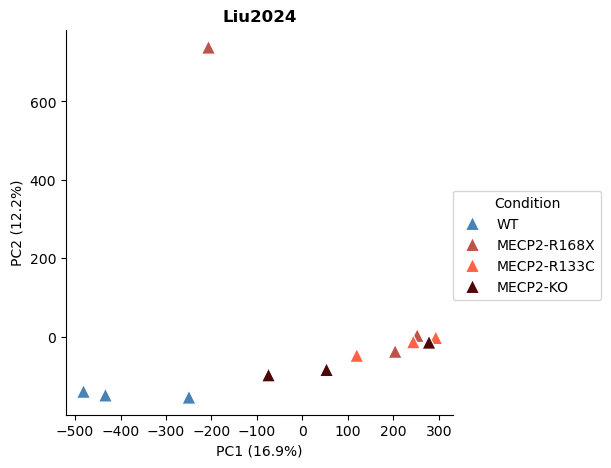

In [7]:
fig, ax = plt.subplots(figsize = (5 ,5))

palette_pca = {
    'MECP2-KO' : '#4E0707',
    'MECP2-R133C' : 'tomato',
    'MECP2-R168X' : '#BC544B',
    'WT' : 'steelblue'
}

pca_df['genotype'] = pca_df['genotype'].replace({'MECP2.KO' : 'MECP2-KO', 'MECP2.R133C' : 'MECP2-R133C', 'MECP2.R168X' : 'MECP2-R168X',
                                                   'MECP2.WT' : 'WT'})
sns.scatterplot(pca_df, x = 'PC1', y = 'PC2', hue = 'genotype', palette = palette_pca, s = 100, marker = '^')

# Labels
ax.set_title('Liu2024', fontweight = 'bold', fontsize = 12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))

sns.despine()
plt.show()